# GMM Exploration on the Michelson data

Now that we have the Michelson data in a good position, we can start working on the GMM to help quantify some distance, with some additions. 

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.mixture import GaussianMixture
import helpers.generate_planet_list as helpers
import helpers.generate_galaxy_data as galaxy_helpers
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

SpeciesInit()
db = Database()

def balanced_accuracy_score(y_true, y_pred):
    recall_0 = np.sum((y_true == 0) & (y_pred == 0)) / np.sum(y_true == 0)
    recall_1 = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1)
    balanced_accuracy = (recall_0 + recall_1) / 2
    return balanced_accuracy


db.add_model('sonora-bobcat', wavel_range=(0.61, 17.0), wavel_sampling=1000.0)

bobcat_model = ReadModel('sonora-bobcat')
bobcat_planets = helpers.generate_planet_arrays(bobcat_model, radius_range=(0.6, 1.3), distance=10, num_samples=400)

bobcat_planets = helpers.update_planet_flux_and_magnitude(bobcat_model, bobcat_planets, ['JWST/MIRI.F1065C', 'JWST/MIRI.F1140C', 'JWST/MIRI.F1550C'])
bobcat_planets = helpers.add_color_columns(bobcat_planets, ['F1065C', 'F1140C', 'F1550C'])
names, colors = helpers.color_color_matrix(bobcat_planets)

AGN_00_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR0.0.txt')
AGN_05_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR0.5.txt')
AGN_10_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR1.0.txt')
# get all of the dwarf planet colors for the first color

d_color_1 = colors[:, 0]
d_color_2 = colors[:, 1]
d_color_3 = colors[:, 2]

g_00_color_1 = AGN_00_data[names[0]]
g_05_color_1 = AGN_05_data[names[0]]
g_10_color_1 = AGN_10_data[names[0]]

g_00_color_2 = AGN_00_data[names[1]]
g_05_color_2 = AGN_05_data[names[1]]
g_10_color_2 = AGN_10_data[names[1]]

g_00_color_3 = AGN_00_data[names[2]]
g_05_color_3 = AGN_05_data[names[2]]
g_10_color_3 = AGN_10_data[names[2]]

all_g_color_1 = np.concatenate((g_00_color_1, g_05_color_1, g_10_color_1))
all_g_color_2 = np.concatenate((g_00_color_2, g_05_color_2, g_10_color_2))
all_g_color_3 = np.concatenate((g_00_color_3, g_05_color_3, g_10_color_3))

all_color_1 = np.concatenate((d_color_1, all_g_color_1))
all_color_2 = np.concatenate((d_color_2, all_g_color_2))
all_color_3 = np.concatenate((d_color_3, all_g_color_3))

X = np.column_stack((all_color_1, all_color_2))
Y = np.concatenate((np.zeros(len(d_color_1)), np.ones(len(all_g_color_1))))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, random_state=0)





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed

-------------------------
Add grid of model spectra
-------------------------

Database tag: sonora-bobcat
Model name: Sonora Bobcat

Unpacking 1131/1131 model spectra from Sonora Bobcat (392 MB)... [DONE]

Please cite Marley et al. (2021) when using Sonora Bobcat in a publication
Reference URL: https://zenodo.org/record/5063476

Wavelength range (um) = 0.61 - 17.0
Sampling (lambda/d_lambda) = 1000.0
Teff range (K) = 200 - 2400

Adding Sonora Bobcat model spectra... data/

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:413: RuntimeWarning: divide by zero encountered in log10
  flux = np.log10(flux)


Balanced accuracy score: 0.5044


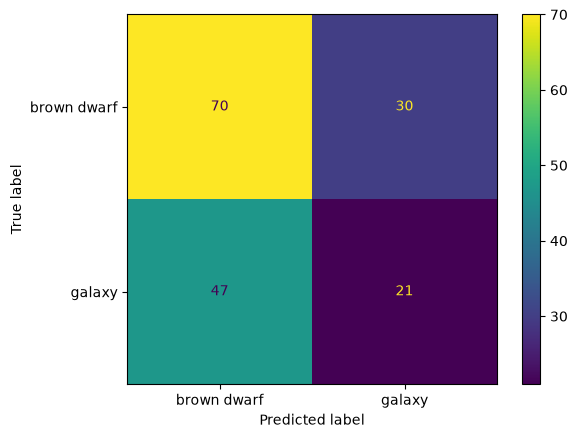

In [ ]:

def fit_and_score(X_train, y_train, X_test, y_test, seed=0):
    gm = GaussianMixture(n_components=2, covariance_type="full",
                         random_state=seed, n_init=10).fit(X_train)

    # Resolve the arbitrary component naming using TRAINING labels only.
    train_pred = gm.predict(X_train)
    flip = (balanced_accuracy_score(y_train, 1 - train_pred)
            > balanced_accuracy_score(y_train, train_pred))

    pred_best = gm.predict(X_test)
    if flip:
        pred_best = 1 - pred_best

    return balanced_accuracy_score(y_test, pred_best), pred_best

score, pred_best = fit_and_score(X_train, Y_train, X_test, Y_test, seed=0)

matrix = ConfusionMatrixDisplay.from_predictions(
    Y_test, pred_best, display_labels=["brown dwarf", "galaxy"]
)
print(f"Balanced accuracy score: {score:.4f}")


In [11]:
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(X, Y, test_size=0.4,
                                          stratify=Y, random_state=seed)
    score, _ = fit_and_score(Xtr, ytr, Xte, yte, seed=seed)
    print(seed, round(score, 3))


0 0.684
1 0.681
2 0.535
3 0.681
4 0.527
5 0.529
6 0.697
7 0.678
8 0.688
9 0.48
10 0.688
11 0.538
12 0.688
13 0.672
14 0.703
15 0.531
16 0.731
17 0.7
18 0.675
19 0.504
